In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import shap
import dalex as dx

# XGBoost

## Data Preprocessing

In [2]:
data = pd.read_csv("dataset_refining/german_credit_data_with_risk.csv")

# Missing values are present in "Checking account" and "Saving accounts". They directly link to 0$, hence we replace them with 0s
data = data.fillna(0)

# Using sex hurts model performance, while also adds unnecessary bias, so we remove it
data.drop(columns=["Sex"], inplace=True)

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    "domestic appliances": 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)

data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
data.replace({"Housing":          {"free": 0, "rent": 1, "own": 2}}, inplace=True)
data["credit_risk"] = data["credit_risk"].map({1: 1, 2: 0})   # good=1, bad=0

data = data.astype({
    "Saving accounts": "int",
    "Checking account": "int",
    "Housing": "int"
})

/tmp/ipykernel_80515/1089702627.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Checking account": {"little": 1, "moderate": 2, "rich": 3}}, inplace=True)
/tmp/ipykernel_80515/1089702627.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Saving accounts":  {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}}, inplace=True)
/tmp/ipykernel_80515/1089702627.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior

In [3]:
X = data.drop(columns=["credit_risk"])
y = data["credit_risk"]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Training

In [4]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False);

## Global Results

In [5]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print("=" * 40)

  Accuracy : 0.8050
  F1 Score : 0.8696
  AUC      : 0.7805


In [6]:
n_rounds = model.n_estimators

acc_train, acc_test = [], []
f1_train,  f1_test  = [], []
auc_train, auc_test = [], []

for i in range(1, n_rounds + 1):
    # --- TRAIN ---
    y_proba_tr = model.predict_proba(X_train, iteration_range=(0, i))[:, 1]
    y_pred_tr  = (y_proba_tr >= 0.5).astype(int)

    acc_train.append(accuracy_score(y_train, y_pred_tr))
    f1_train.append(f1_score(y_train, y_pred_tr))
    auc_train.append(roc_auc_score(y_train, y_proba_tr))

    # --- TEST ---
    y_proba_te = model.predict_proba(X_test, iteration_range=(0, i))[:, 1]
    y_pred_te  = (y_proba_te >= 0.5).astype(int)

    acc_test.append(accuracy_score(y_test, y_pred_te))
    f1_test.append(f1_score(y_test, y_pred_te))
    auc_test.append(roc_auc_score(y_test, y_proba_te))

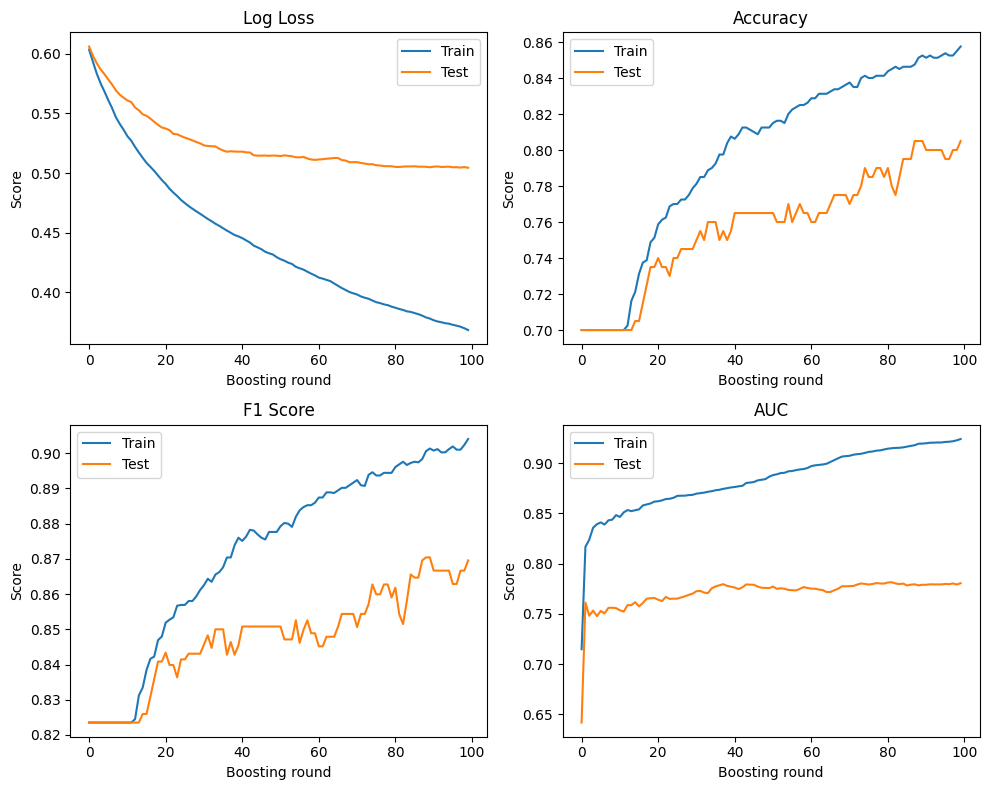

In [7]:
results = model.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss  = results["validation_1"]["logloss"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Logloss ---
axs[0, 0].plot(train_loss, label="Train")
axs[0, 0].plot(test_loss, label="Test")
axs[0, 0].set_title("Log Loss")
axs[0, 0].legend()

# --- Accuracy ---
axs[0, 1].plot(acc_train, label="Train")
axs[0, 1].plot(acc_test, label="Test")
axs[0, 1].set_title("Accuracy")
axs[0, 1].legend()

# --- F1 ---
axs[1, 0].plot(f1_train, label="Train")
axs[1, 0].plot(f1_test, label="Test")
axs[1, 0].set_title("F1 Score")
axs[1, 0].legend()

# --- AUC ---
axs[1, 1].plot(auc_train, label="Train")
axs[1, 1].plot(auc_test, label="Test")
axs[1, 1].set_title("AUC")
axs[1, 1].legend()

for ax in axs.flat:
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

The loss and metrics are slightly lower on training set than on the test set, indicating mild overfitting, but test performance remains strong.

### XGBoost feature importance

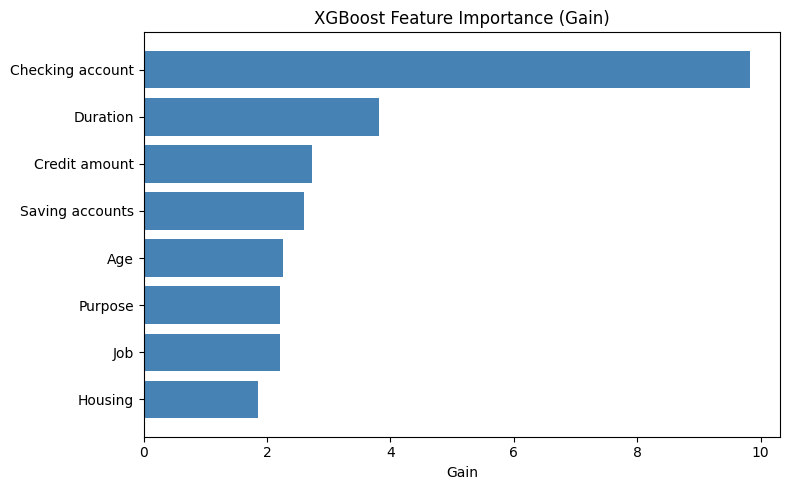

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
importance = model.get_booster().get_score(importance_type="gain")
importance = dict(sorted(importance.items(), key=lambda x: x[1]))
ax.barh(list(importance.keys()), list(importance.values()), color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

The feature importance plot shows that ‘Checking account’ contributes the most to model predictions, followed by ‘Duration’, ‘Saving accounts’, and ‘Credit amount’. Other features such as ‘Age’, ‘Purpose’, ‘Housing’, and ‘Job’ have moderate influence. This ranking aligns with expectations, as financial history and account balances are key factors in predicting credit risk.

### Confusion matrix

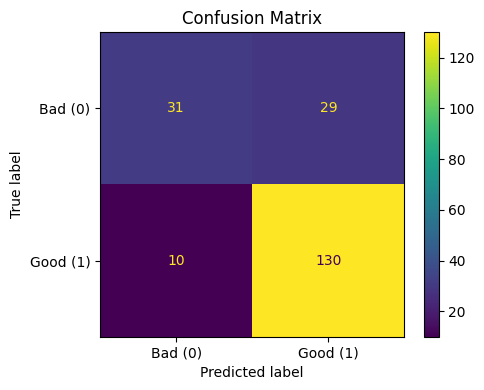

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Bad (0)", "Good (1)"], ax=ax
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts most ‘Good’ cases (130/140) and a smaller portion of ‘Bad’ cases (31/60). Misclassifications occur mostly when a ‘Bad’ credit is predicted as ‘Good’ (28 cases). Overall, the model performs well, with better accuracy on the majority class (‘Good’), and mild overfitting does not appear to affect class separation significantly.

### SHAP summary

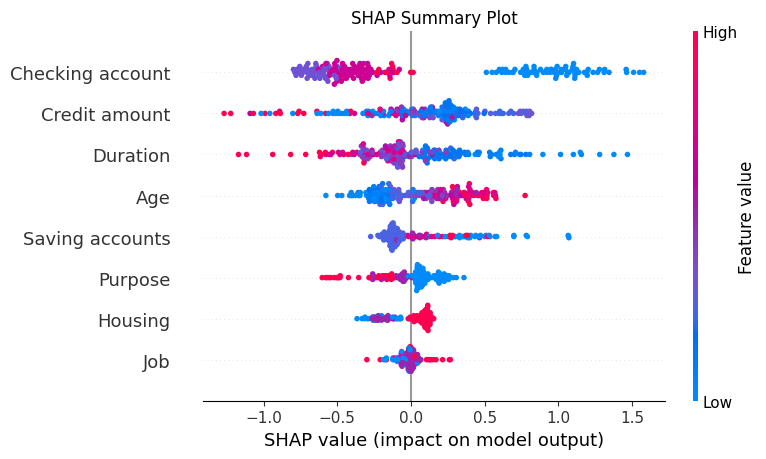

In [10]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

- **Checking account** - surprisingly, a value of `0` (no recorded checking account) contributes positively to good credit risk-likely reflecting individuals who maintain accounts in other banks or have alternative financial arrangements. Small or moderate balances are associated with higher risk, while high balances slightly increase predicted safety.
- **Credit amount** - values are not so well separated, but high values have a very clear negative impact while moderately low values a positive impact. Low values are around `0` likely because for someone with low credit, it is more likely that this low credit is all he can get.
- **Duration** - values in the middle are mixed up, but extremes tell the clear story, long = bad, short = good
- **Age** - Generally higher = better, with experience people generally advance their careers, build their own capital and have greater stability in life
- **Saving Accounts** - here 0 reffers to no saving account and it correlates positively with good risk maybe because those people invest their money outside banks and it serves them better, on the other hand people with rich saving accounts also score well which is obvious. Most people have little money on saving accounts and the model penalizes it slightly
- **Housing** - free or rented is a bad sign, own is a good sign because of greater stability
- **Purpose** - Here high and middle values reffer to ambitious and necessary purposes like school are repairs, it may be that people who take these loans are in a bad position in their life which correlates with bad risk, people who take their loans recklessly for cars and holidays are often in a more stable position
- **Job** - Generally better job is better (lower) credit risk

### SHAP feature importance

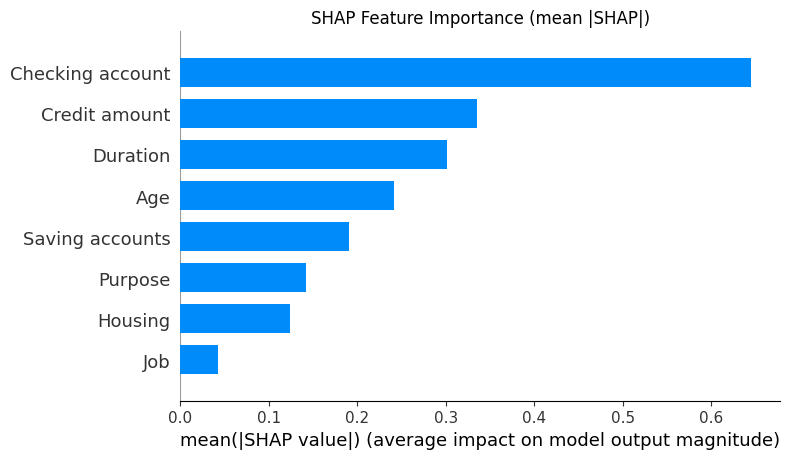

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

The SHAP feature importance shows that `Checking account` is by far the most influential feature, significantly exceeding all others. It is followed by `Credit amount` and `Duration`, indicating that the model relies primarily on financial attributes. `Age` and `Saving accounts` have moderate importance, while `Housing`, `Purpose`, and especially `Job` contribute relatively little to the model's predictions.

## Sample Analysis

In [12]:
def plot_shap_waterfall(model, sample):
    # Ensure we have an explainer
    explainer = shap.TreeExplainer(model)

    # compute SHAP values for the sample
    shap_values = explainer.shap_values(sample)

    # get index 0 because it's a single-row DataFrame
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[0],
        feature_names=sample.columns,
        max_display=10
    )

    logit = explainer.expected_value + shap_values.sum()
    delta_logit = 0 - logit  # amount needed to flip class
    print(f"Current class: {int(logit > 0)}, amount needed to flip the class: {delta_logit:.4f}")

In [13]:
def minimal_flip(model, X_test, idx, feature, max_steps=100, step_fraction=0.01, direction=1):
    X_sample = X_test.iloc[[idx]].copy()
    original_class = model.predict(X_sample)[0]
    
    # Determine step size
    if X_sample[feature].dtype.kind in 'iuf':  # numeric
        step = step_fraction * (X_test[feature].max() - X_test[feature].min())
        if X_sample[feature].dtype.kind in 'i':
            step = max(1, round(step))
    else:  # categorical
        step = 1
    
    # Iteratively perturb
    sample_cf = X_sample.copy()
    for i in range(1, max_steps + 1):
        if X_sample[feature].dtype.kind in 'iuf':
            sample_cf[feature] += step * direction
        else:
            # for categorical: move to next ordinal category
            sample_cf[feature] = int(sample_cf[feature] + step * direction)
        
        new_class = model.predict(sample_cf)[0]
        if new_class != original_class:
            return {
                'original_class': original_class,
                'flipped_class': new_class,
                'feature': feature,
                'total_change': step * i,
                'steps': i,
                'sample_cf': sample_cf
            }
    
    # If not flipped
    return {
        'original_class': original_class,
        'flipped_class': original_class,
        'feature': feature,
        'total_change': 0,
        'steps': 0,
        'sample_cf': sample_cf
    }

### Sample selection

In [14]:
# predicted probabilities for class 1 (Good)
probas = model.predict_proba(X_test)[:, 1]
preds  = model.predict(X_test)

idx_1 = 15
idx_2 = 73
idx_3 = 118

print(f"Probability {idx_1}:", probas[idx_1])
print(f"Probability {idx_2}:", probas[idx_2])
print(f"Probability {idx_3}:", probas[idx_3])

Probability 15: 0.5178642
Probability 73: 0.56484336
Probability 118: 0.51054645


### Sample 15

#### Analytical

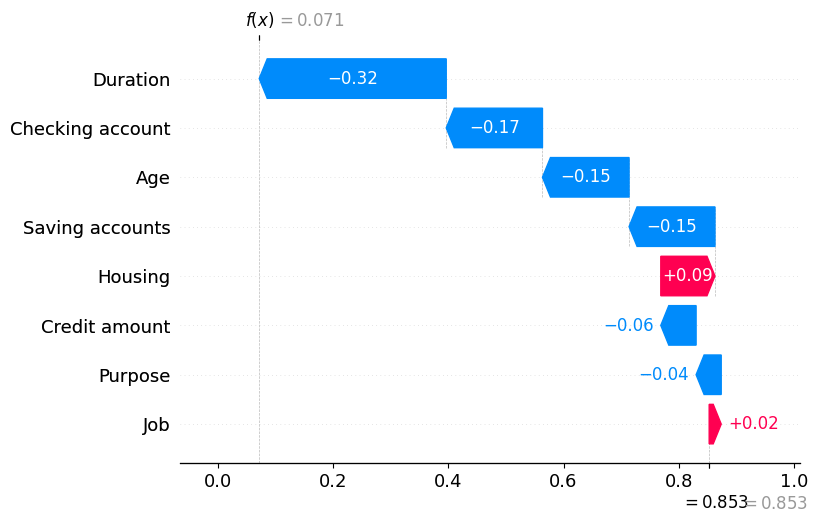

Current class: 1, amount needed to flip the class: -0.0715


In [15]:
plot_shap_waterfall(model, X_test.iloc[[15]])

In [16]:
sample = X_test.iloc[[15]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
248,26,2,2,1,3,1925,24,1


Checking account - the most influential attribute is quite high, by reducing it I will surely be able to switch the class. Right now we are missing `-0.0715` shap value.

In [17]:
feature_name = "Checking account"
feature_idx = X_test.columns.get_loc(feature_name)

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

grouped = X_test.copy()
grouped['shap_value'] = checking_shap

avg_by_value = grouped.groupby(feature_name)['shap_value'].mean()
print(avg_by_value)
print("Difference in average shap value contribution between 2nd and 3rd category of 'Checkout account'", avg_by_value[2] - avg_by_value[3])

Checking account
0    0.979801
1   -0.644259
2   -0.381381
3   -0.169141
Name: shap_value, dtype: float32
Difference in average shap value contribution between 2nd and 3rd category of 'Checkout account' -0.21223998


The difference is much larger than `-0.0715`, so this will probably be enough to switch the class, also the change in this criterion can't be smaller.

In [18]:
sample['Checking account'] = 2

In [19]:
model.predict_proba(sample)

array([[0.57226884, 0.42773116]], dtype=float32)

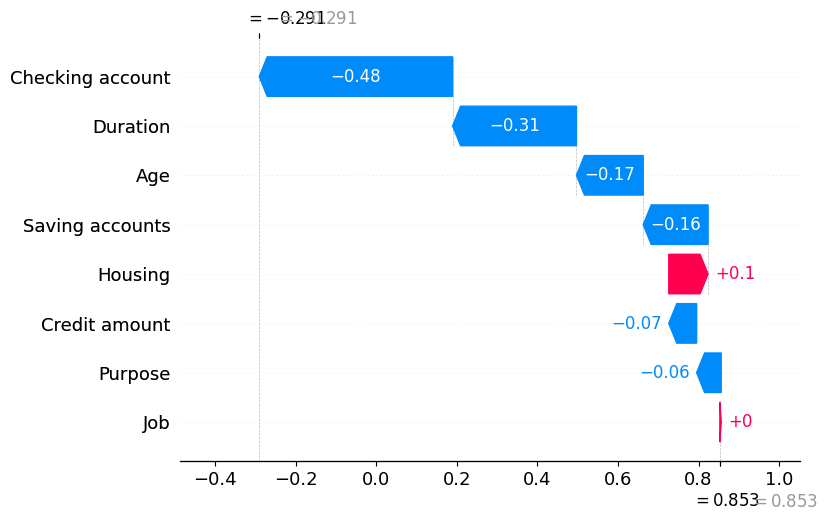

Current class: 0, amount needed to flip the class: 0.2911


In [20]:
plot_shap_waterfall(model, sample)

#### Sampling

In [21]:
res = minimal_flip(model, X_test, 15, feature="Checking account", max_steps=100, step_fraction=0.01, direction=-1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Checking account',
 'total_change': 1,
 'steps': 1,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 248   26    2        2                1                 2           1925   
 
      Duration  Purpose  
 248        24        1  }

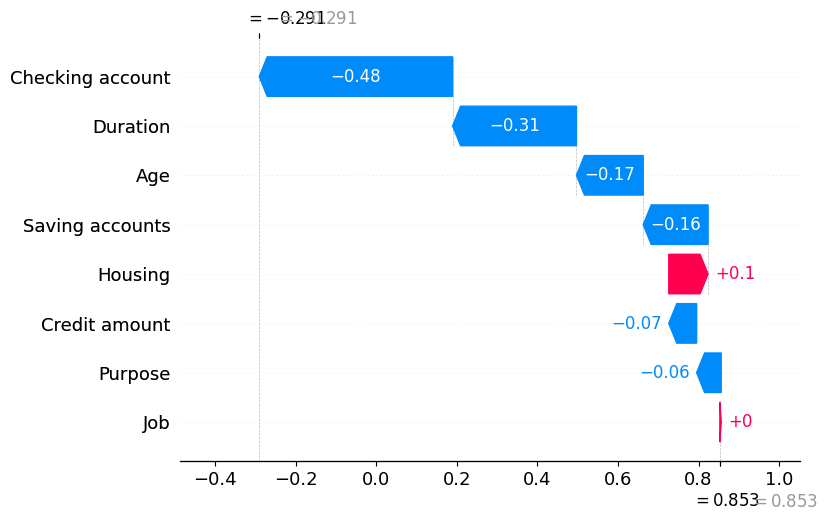

Current class: 0, amount needed to flip the class: 0.2911


In [22]:
plot_shap_waterfall(model, res["sample_cf"])

1 step in 'Checking account' was needed just as expected, this one was trivial because 'Checking account' has only 4 possible vaslues and huge impact on the prediction

### Sample 73

#### Analytical

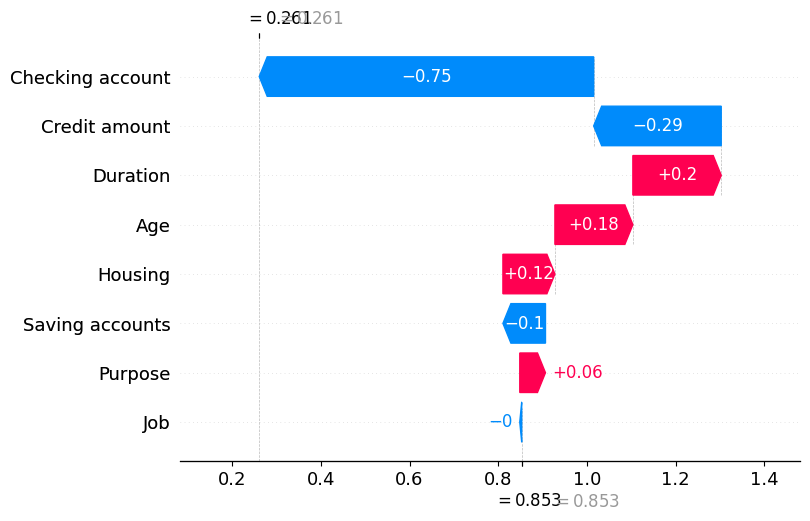

Current class: 1, amount needed to flip the class: -0.2608


In [23]:
plot_shap_waterfall(model, X_test.iloc[[73]])

In [24]:
sample = X_test.iloc[[73]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
929,43,1,2,1,1,1344,12,0


This person is quite old, from the SHAP summary plot we can see that Age is pretty well corelated with positive SHAP values, hence by reducing the age we should easily get some lower SHAP values and eventually reach the `bad risk` class.

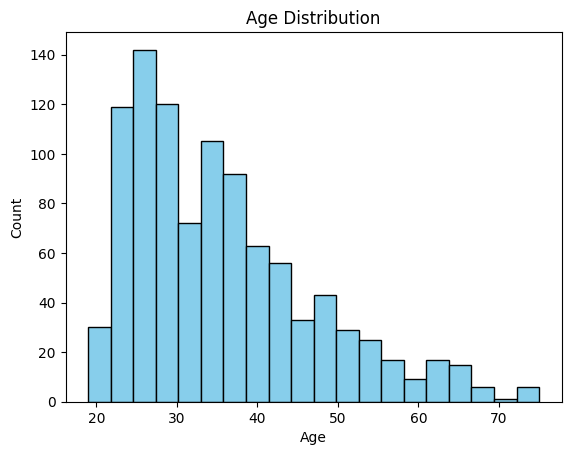

In [25]:
plt.hist(data['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [26]:
feature_name = "Age"
feature_idx = X_test.columns.get_loc(feature_name)

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

grouped = X_test.copy()
grouped['shap_value'] = checking_shap

avg_by_value = grouped.groupby(feature_name)['shap_value'].mean()
print(avg_by_value)
print("Difference in average shap value contribution between 43 and 34 years", avg_by_value[43] - avg_by_value[34])

Age
19   -0.160778
20    0.000541
21   -0.474717
22   -0.330938
23   -0.259166
24   -0.267975
25   -0.224174
26   -0.235861
27   -0.199077
28   -0.216607
29   -0.248583
30   -0.064256
31   -0.113803
32   -0.055099
33   -0.102668
34   -0.024655
35    0.100515
36    0.120629
37    0.253547
38    0.193745
39    0.293899
40    0.280126
41    0.160480
42    0.240872
43    0.224537
44    0.258012
45    0.391751
46    0.371411
47    0.390035
48    0.369953
49    0.546997
50    0.268862
51    0.482524
52    0.405718
53    0.363449
54    0.399449
55    0.287005
56    0.399161
57    0.332147
60    0.090760
61    0.366479
65    0.774377
67    0.514893
74    0.568073
Name: shap_value, dtype: float32
Difference in average shap value contribution between 43 and 34 years 0.24919195


Given this distribution, the age of `43` is probably purple on the SHAP summary plot so there is definetly some room for improvemnt going into blues, however the `Age` attribute is moderately important and even low values can have a positive impact so despite I am not lacking much to reach the other class, I need a moderate change to see an actual difference in this criterion, this is backed by the average shap value contribution, where the difference is closest ot what I need for an age of `32`hence I will go wit it.

In [27]:
sample["Age"] = 34

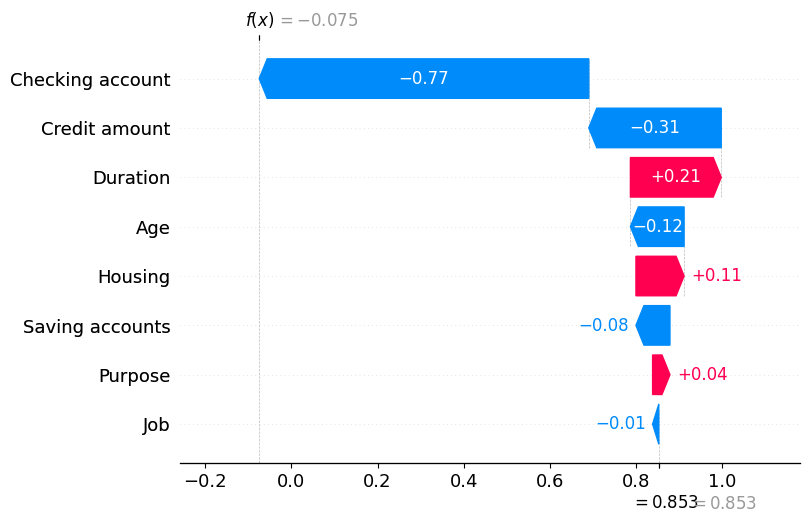

Current class: 0, amount needed to flip the class: 0.0746


In [28]:
plot_shap_waterfall(model, sample)

#### Sampling

In [29]:
res = minimal_flip(model, X_test, 73, feature="Age", max_steps=100, step_fraction=0.01, direction=-1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Age',
 'total_change': 9,
 'steps': 9,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 929   34    1        2                1                 1           1344   
 
      Duration  Purpose  
 929        12        0  }

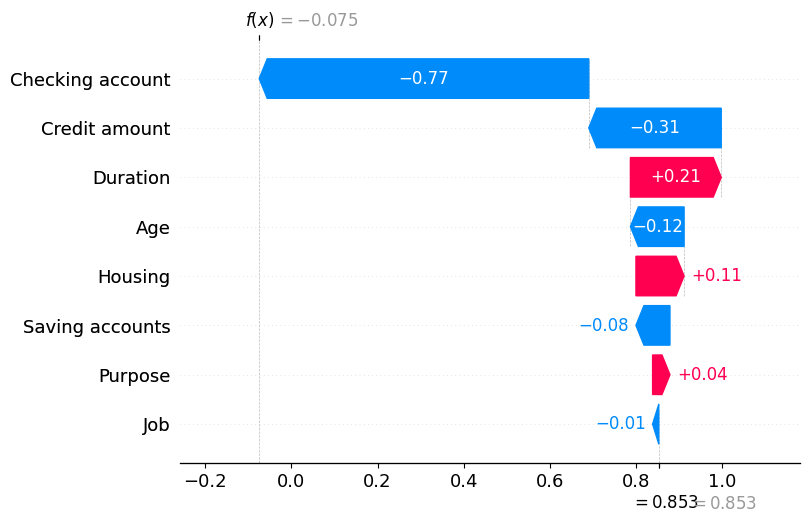

Current class: 0, amount needed to flip the class: 0.0746


In [30]:
plot_shap_waterfall(model, res["sample_cf"])

I was right - the class switches at 34 years old

### Sample 118

#### Analytical

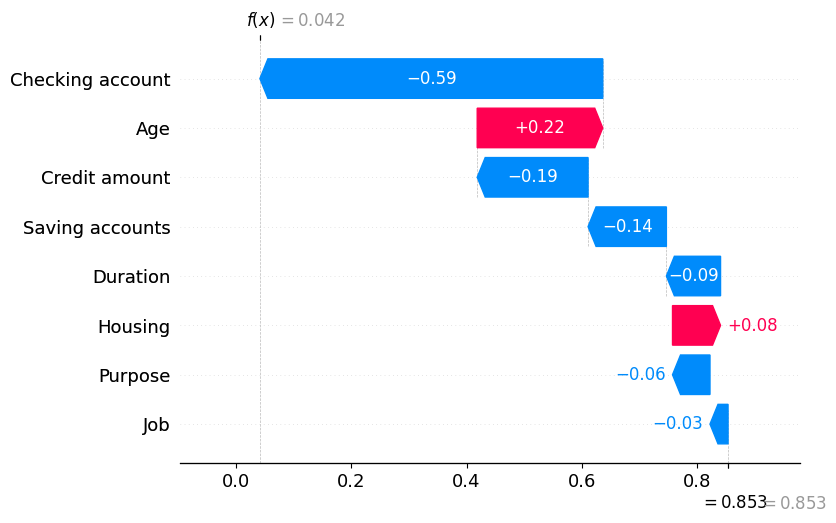

Current class: 1, amount needed to flip the class: -0.0422


In [31]:
plot_shap_waterfall(model, X_test.iloc[[118]])

In [32]:
sample = X_test.iloc[[118]].copy()
sample

,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
924,55,2,2,1,1,6872,24,1


In [33]:
feature_name = "Duration"
feature_idx = X_test.columns.get_loc(feature_name)

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

# shap_values is an array of shape (n_samples, n_features)
checking_shap = shap_values[:, feature_idx]

grouped = X_test.copy()
grouped['shap_value'] = checking_shap

avg_by_value = grouped.groupby(feature_name)['shap_value'].mean()
print(avg_by_value)
# print("Difference in average shap value contribution between 43 and 34 years", avg_by_value[43] - avg_by_value[34])

Duration
5     0.435530
6     0.840920
7     1.058602
8     0.890354
9     0.503164
10    0.494913
11    0.576809
12    0.190081
15    0.175287
18   -0.140025
20   -0.045689
21   -0.079102
24   -0.121363
27   -0.039003
30   -0.013022
33   -0.544095
36   -0.278913
39   -0.156943
45   -0.574110
48   -0.700728
60   -0.647819
Name: shap_value, dtype: float32


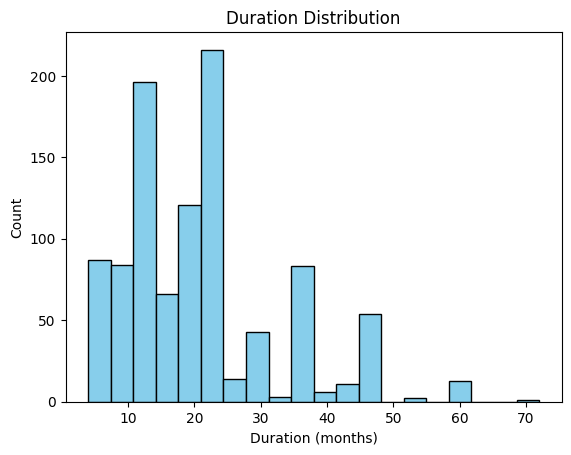

In [34]:
plt.hist(data['Duration'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Duration (months)')
plt.ylabel('Count')
plt.title('Duration Distribution')
plt.show()

This time I will tamper with Duration for diversity and because this person has `24` in this field which is on the lower side of the distribution, from the SHAP summary plot we can see that Duration is spread across a big range of SHAP values and extremes can make a significant difference here, the moderate values however are ranigng around 0, so I should aim for large change here if I want to make sure there is a difference, this is also confirmed by average shap value contribution on this criterion where the differences between consecutive values are large and irregular. I'd say `33` looks reasonable, it is far enough from `24` and is already outside the range where most instances lay.

In [35]:
sample["Duration"] = 33

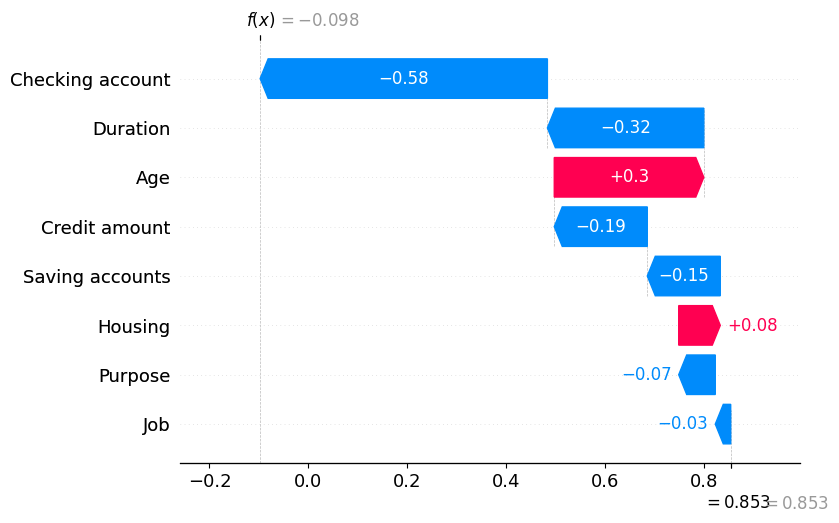

Current class: 0, amount needed to flip the class: 0.0976


In [36]:
plot_shap_waterfall(model, sample)

#### Sampling

In [37]:
res = minimal_flip(model, X_test, 118, feature="Duration", max_steps=100, step_fraction=0.01, direction=1)
res

{'original_class': np.int64(1),
 'flipped_class': np.int64(0),
 'feature': 'Duration',
 'total_change': 4,
 'steps': 4,
 'sample_cf':      Age  Job  Housing  Saving accounts  Checking account  Credit amount  \
 924   55    2        2                1                 1           6872   
 
      Duration  Purpose  
 924        28        1  }

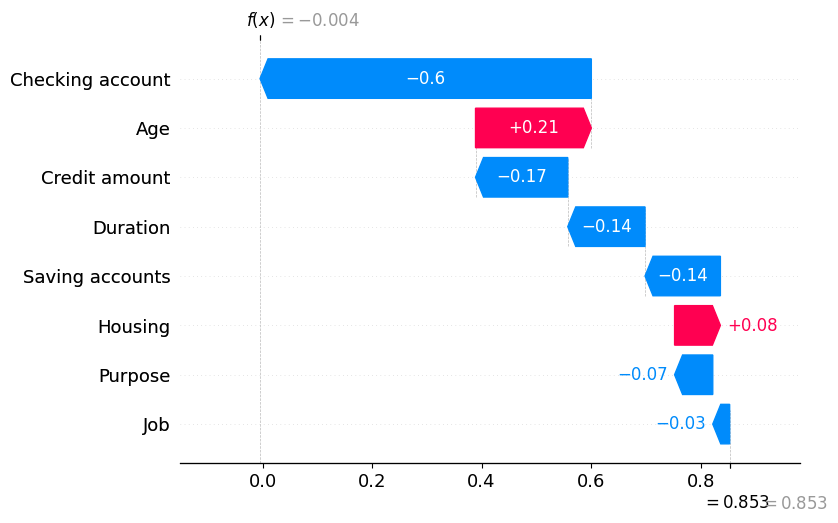

Current class: 0, amount needed to flip the class: 0.0045


In [38]:
plot_shap_waterfall(model, res["sample_cf"])

This time I overshot by a lot, I think that the distribution shape was crucial here as `28` is where there are much fewer samples in the dataset above this treshold and that is why important treshold in XGBoost model was here.

## Interpretation of the model

In [39]:
explainer = dx.Explainer(
    model,
    X_test,
    y_test,
    label="XGBoost"
)

Preparation of a new explainer is initiated

  -> data              : 200 rows 8 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 200 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : XGBoost
  -> predict function  : <function yhat_proba_default at 0x7f770333d0c0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.2, mean = 0.691, max = 0.977
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.965, mean = 0.0089, max = 0.743
  -> model_info        : package xgboost

A new explainer has been created!


### Q1

Based on the parameters obtained, can we say something about the user’s preferences?

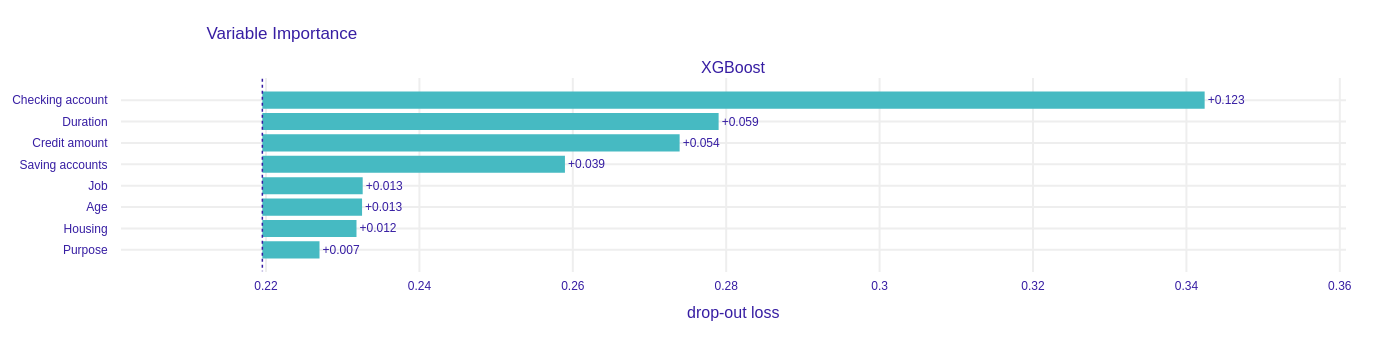

In [40]:
# Global feature importance
vi = explainer.model_parts()
vi.plot()

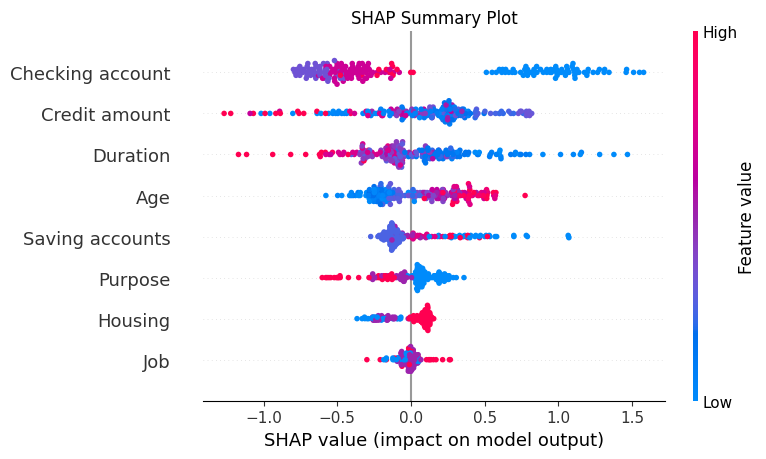

In [41]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

Based on the model parameters and interpretation techniques, we can infer that the decision-maker exhibits a risk-averse preference structure.

The most influential criteria - `Checking account`, `Credit amount`, and `Duration` - indicate that liquidity and debt burden are the primary drivers of decisions. `Credit amount` and `Duration` act as cost criteria, where higher values significantly decrease the likelihood of a favorable classification, while `Age` and `Housing` behave as gain criteria, reflecting preference for stability and experience.

The model also captures nonlinear and threshold-based preferences, particularly for `Duration`, where longer loan periods sharply increase risk. Additionally, some criteria, such as `Saving accounts` and `Checking account`, exhibit non-monotonic behavior, suggesting either complex interactions or dataset-specific effects rather than clear economic preferences.

The relatively low importance of `Purpose`, `Job`, and `Housing` indicates that these factors play a secondary role in the decision process.

Overall, the inferred preferences prioritize financial stability, low indebtedness, and shorter financial commitments, reflecting a conservative and risk-sensitive decision policy.

### Q2

What was the influence of the criteria? Are there any criteria that have no effect, or have a decisive influence?

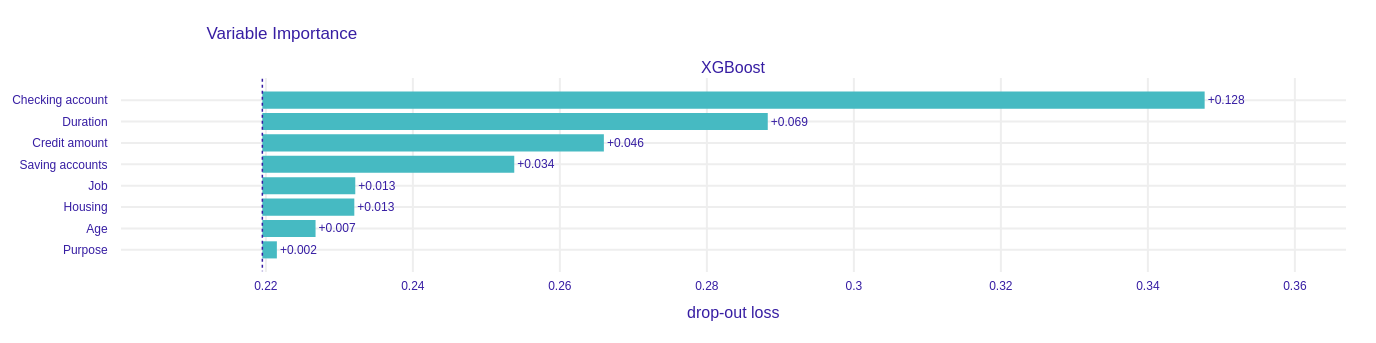

In [42]:
# Global feature importance
vi = explainer.model_parts()
vi.plot()

Based on permutation feature importance (DALEX), the most influential criteria are **Checking account**, **Duration**, **Credit amount** and **Saving accounts** as removing them leads to the largest increase in model error. These variables can therefore be considered decisive for the model’s predictions.

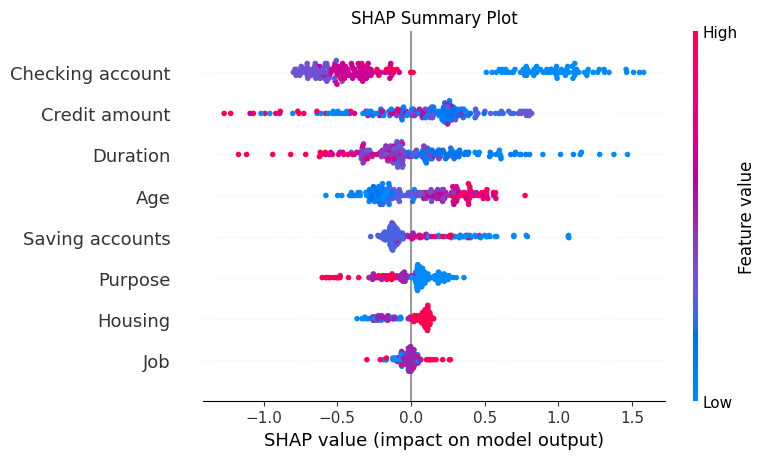

In [43]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

This is consistent with SHAP analysis, where these features exhibit the largest spread of SHAP values, indicating a strong impact on individual predictions.

On the other hand, **Purpose**, **Housing** and **Job** show very low importance in DALEX and minimal variation in SHAP values, suggesting that they have little to no effect on the model’s decisions.

An interesting discrepancy appears for **Age**, which is rated highly by SHAP but relatively low by DALEX. This suggests that while Age influences individual predictions, its overall contribution to model performance is limited, possibly due to redundancy with other variables.

Overall, the model relies heavily on a small subset of criteria - primarily **Checking account**, **Credit amount**, **Duration** and **Saviong accounts** - which have a decisive influence on predictions. Several other variables, such as **Purpose**, **Housing** and **Job**, have negligible impact and could potentially be removed without significantly affecting model performance. The combination of DALEX and SHAP confirms that the model is driven by a few dominant features, while the remaining criteria play a marginal or supportive role.

### Q3

Are there any dependencies between the criteria?

In [44]:
explainer_shap = shap.TreeExplainer(model)
interaction_values = explainer_shap.shap_interaction_values(X_test)

interaction_strength = np.abs(interaction_values).mean(axis=0)

np.fill_diagonal(interaction_strength, 0)

feature_names = X_test.columns

pairs = []

n = interaction_strength.shape[0]

for i in range(n):
    for j in range(i + 1, n):  # avoid duplicates
        pairs.append({
            "feature_1": feature_names[i],
            "feature_2": feature_names[j],
            "strength": interaction_strength[i, j]
        })

df_interactions = pd.DataFrame(pairs)
df_interactions = df_interactions.sort_values(by="strength", ascending=False)

df_interactions.head(10)

,feature_1,feature_2,strength
25,Credit amount,Duration,0.098714
23,Checking account,Duration,0.086164
22,Checking account,Credit amount,0.076603
24,Checking account,Purpose,0.075771
5,Age,Duration,0.036523
18,Saving accounts,Checking account,0.035168
20,Saving accounts,Duration,0.033449
3,Age,Checking account,0.029585
19,Saving accounts,Credit amount,0.029187
4,Age,Credit amount,0.028076


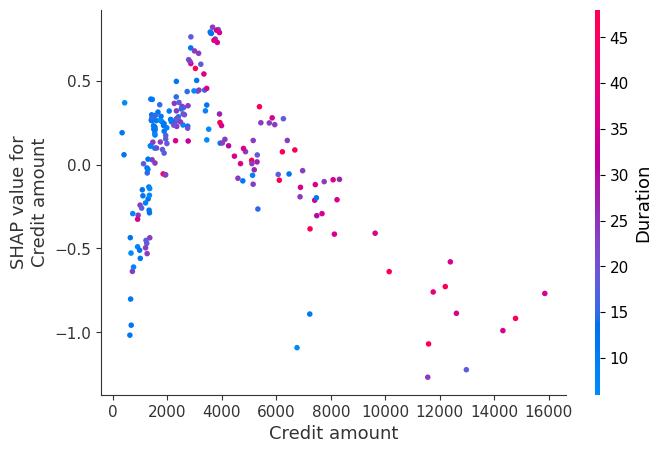

In [45]:
shap.dependence_plot(
    "Credit amount", 
    shap_values, 
    X_test,
    interaction_index="Duration"
)

The strongest interaction is observed between **Credit amount** and **Duration**, indicating that the impact of credit amount on the prediction depends on the loan duration.

The SHAP dependence plot confirms this, as the contribution of **Credit amount** varies significantly across different values of **Duration**. For higher durations, large credit amounts lead to a stronger negative impact on the prediction, whereas for shorter durations, this effect is less pronounced.

The table shows additional interacting pairs, although their interaction strength is weaker, indicating that their effects are closer to additive and less dependent on each other.

For weaker interactions, the dependence plots show less variation across the conditioning feature, indicating limited dependency.

Overall, the model captures dependencies primarily between loan-related variables (**Credit amount**, **Duration**) and financial capacity variables (**Checking account**, **Saving accounts**), indicating that the decision process evaluates criteria jointly rather than independently. However, most interactions are relatively weak, suggesting that the model is still largely additive with a few key dependencies.

### Q4

What is the nature of the criterion, gain, cost, non-monotonic?

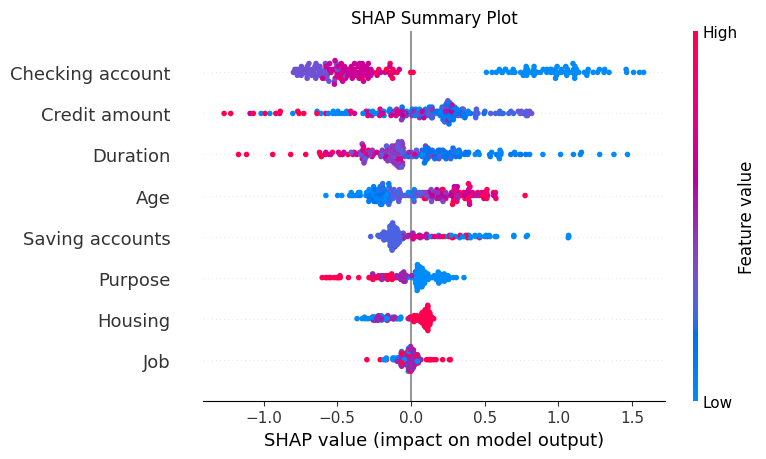

In [46]:
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 50.45it/s]


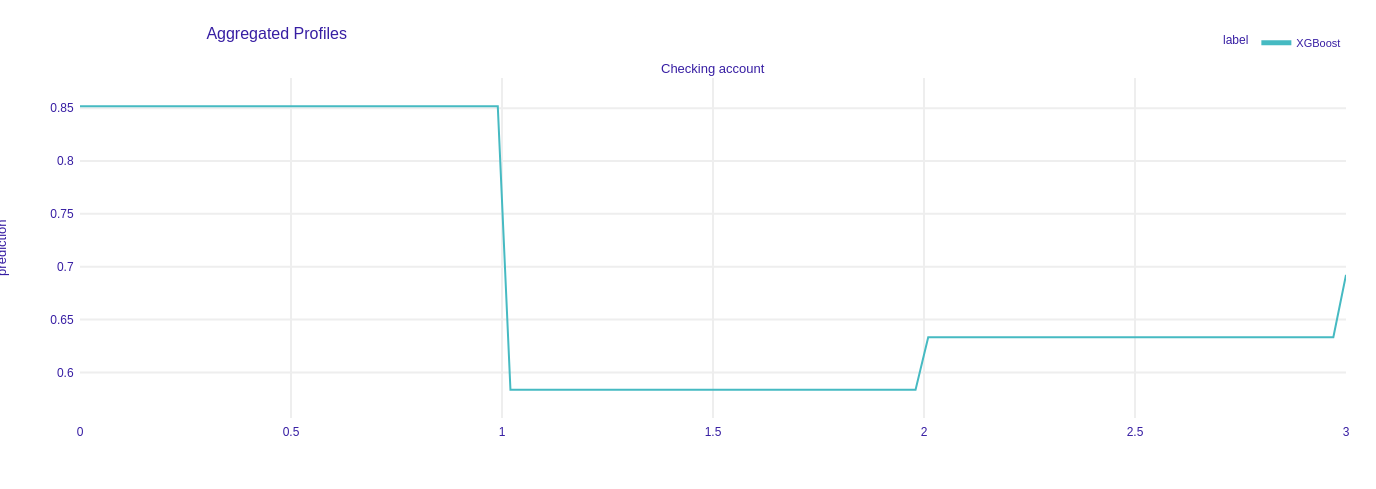

In [47]:
explainer.model_profile(variables=["Checking account"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 62.09it/s]


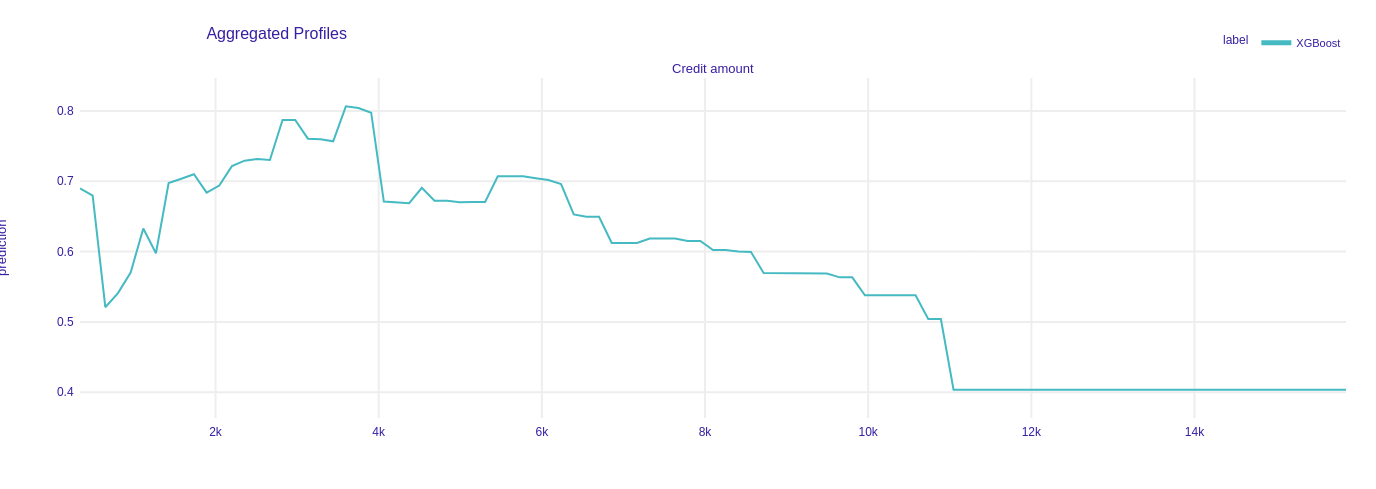

In [48]:
explainer.model_profile(variables=["Credit amount"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 49.47it/s]


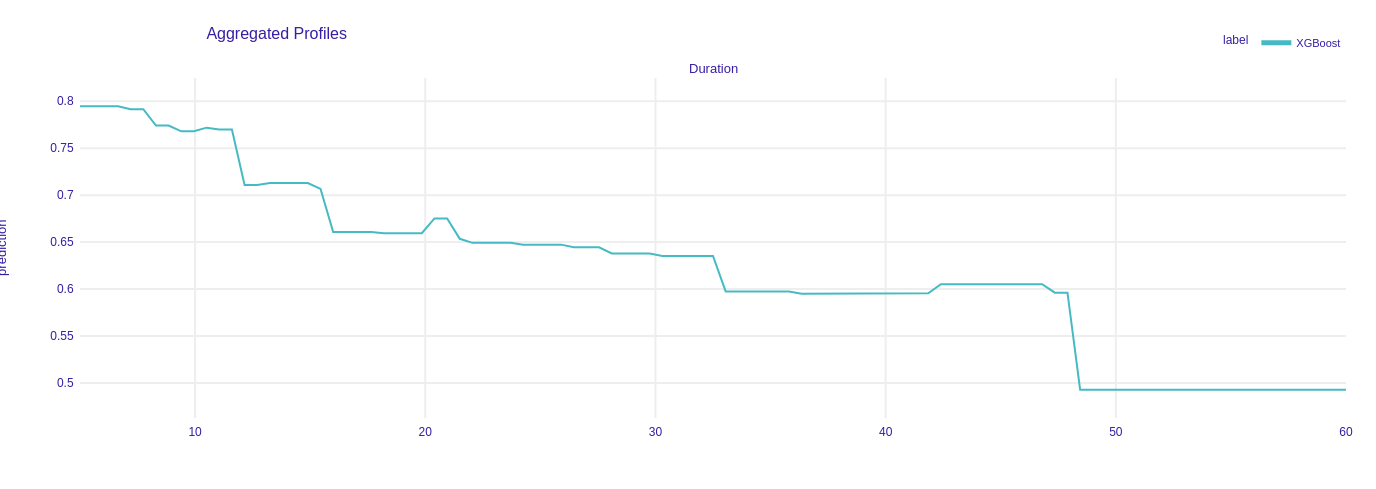

In [49]:
explainer.model_profile(variables=["Duration"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 28.31it/s]


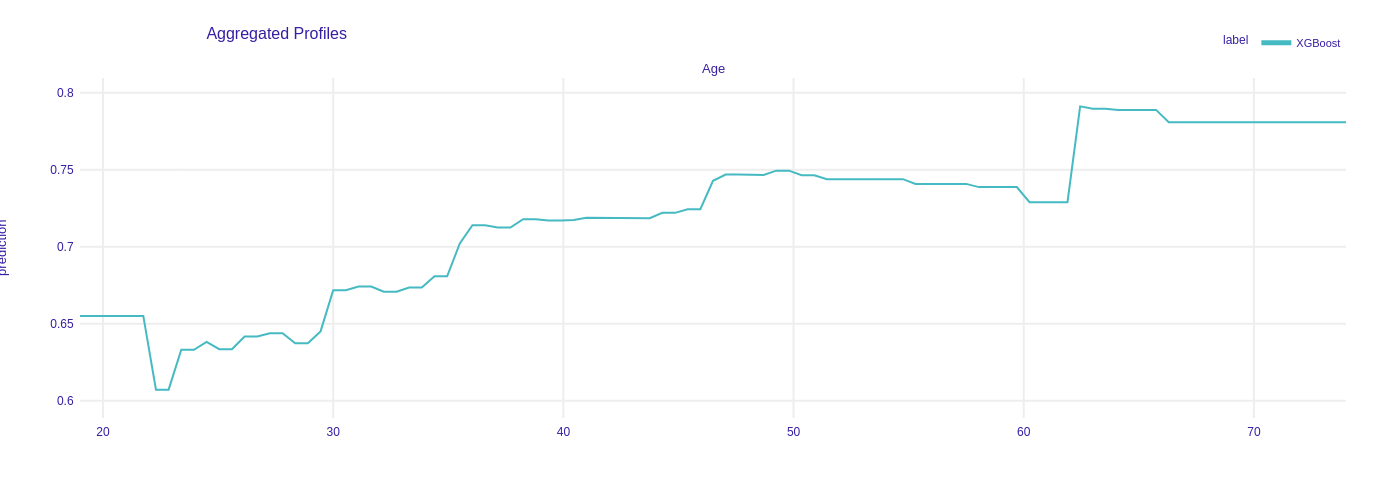

In [50]:
explainer.model_profile(variables=["Age"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 29.36it/s]


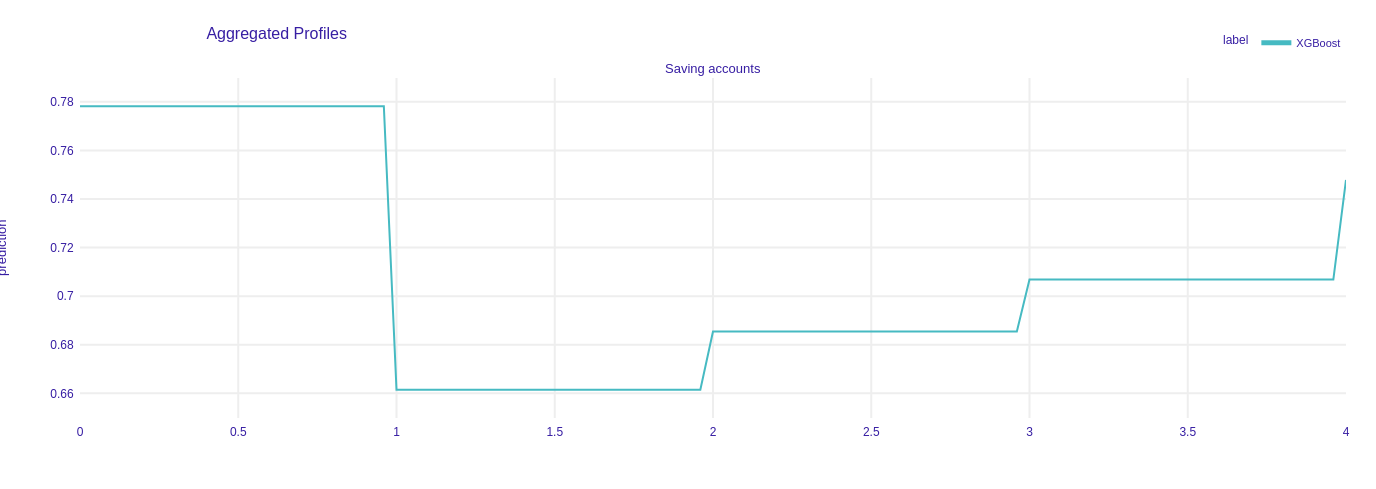

In [51]:
explainer.model_profile(variables=["Saving accounts"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.20it/s]


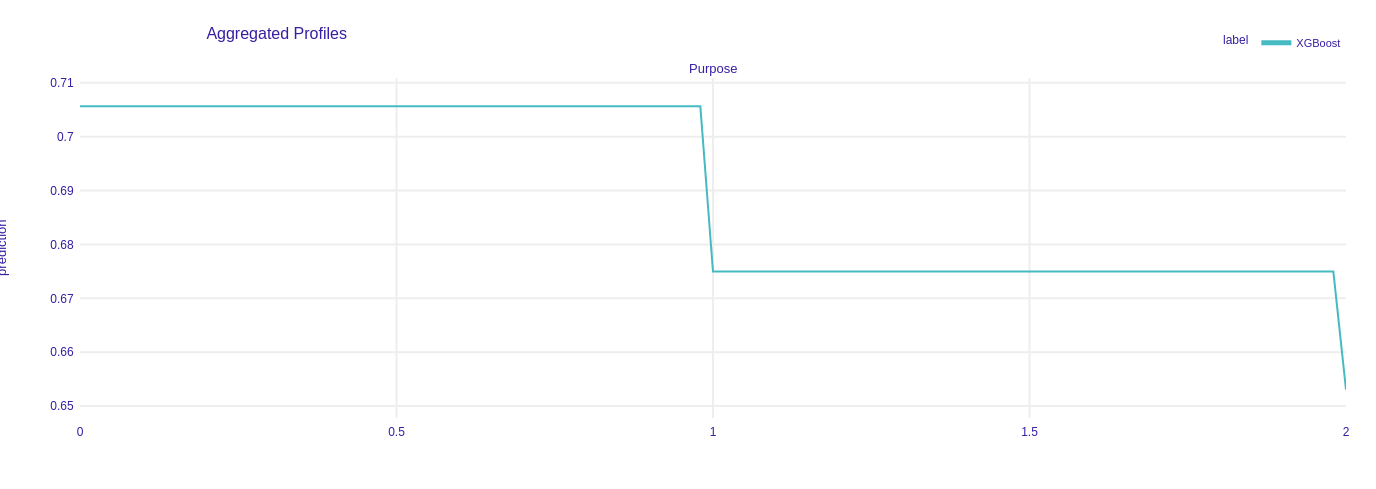

In [52]:
explainer.model_profile(variables=["Purpose"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 90.89it/s]


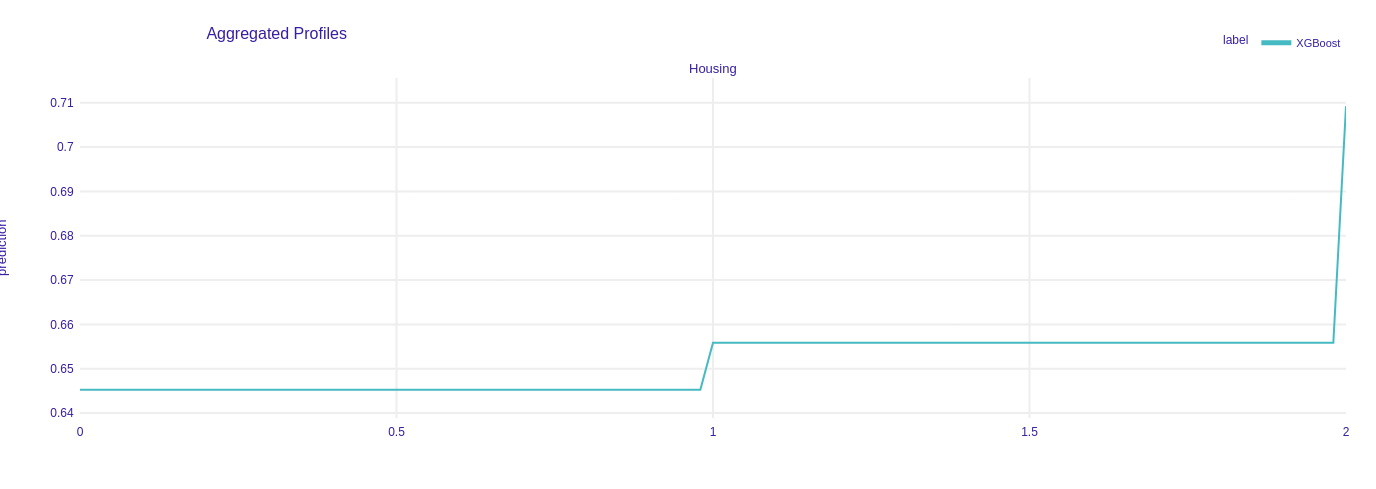

In [53]:
explainer.model_profile(variables=["Housing"]).plot()

Calculating ceteris paribus: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.79it/s]


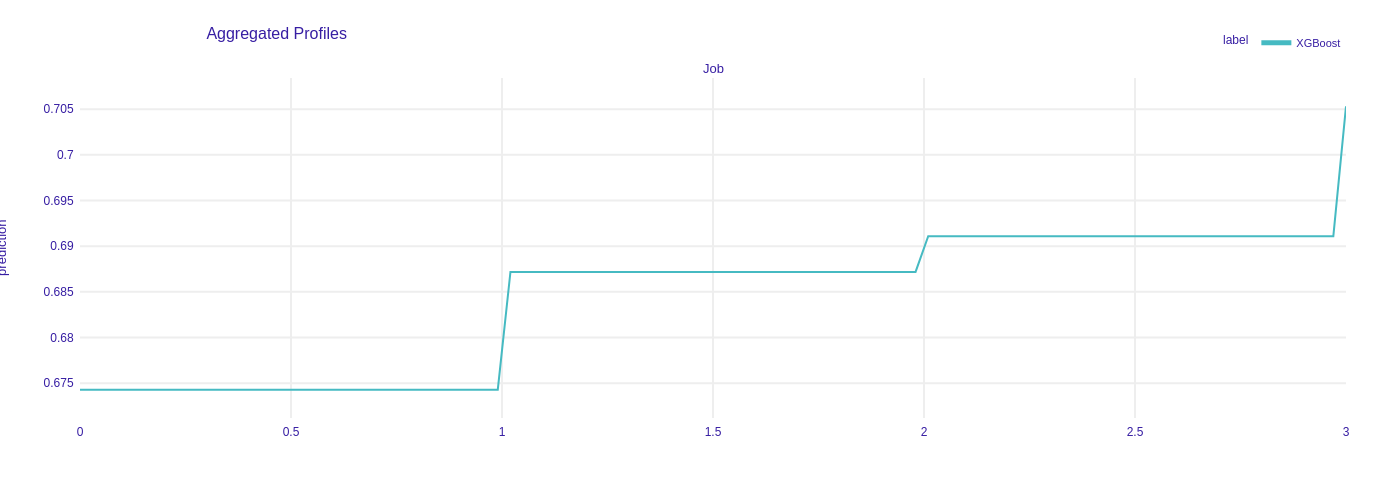

In [54]:
explainer.model_profile(variables=["Job"]).plot()

The nature of the criteria was determined using SHAP summary plots and DALEX partial dependence profiles.

`Checking account` exhibits monotonic behavior for values 1–3, where increasing values correspond to increasingly favorable predictions. However, the value 0 deviates from this trend and is associated with the most positive contribution, breaking strict monotonicity. This indicates a special-case category effect, resulting in overall non-monotonic behavior with a structured pattern.

`Credit amount` behaves primarily as a cost criterion, although noticeable non-monotonicity is present. Mid-range values are associated with more favorable outcomes, while both very low and very high values increase risk, suggesting the existence of an optimal interval rather than a purely monotonic relationship.

`Duration` is a clear cost criterion, with longer durations consistently leading to worse predictions. This is strongly supported by both SHAP values and the decreasing trend in the partial dependence plot.

`Age` exhibits gain-type behavior, as higher values generally contribute positively to the prediction, which is visible in both SHAP value distribution and the upward trend in the partial dependence plot.

`Saving accounts` follows a pattern similar to Checking account, where most categories show an increasing trend in contribution, but for class 0 it deviates from this ordering. This results in structured but not strictly monotonic behavior.

`Purpose` demonstrates a monotonic trend, where higher encoded values are generally associated with less favorable outcomes. Although some variability exists, both SHAP and partial dependence plots indicate an overall cost-type tendency.

`Housing` shows a gain-type tendency, where more stable housing situations correspond to better predictions, the extreme value is highly separated from the rest, while the lower values are more mixed up, showing a moderate monotonocity.

`Job` demonstrates a weak monotonic trend, with higher job categories slightly improving predictions; however, the SHAP distribution indicates that this effect is not strong and may depend on other variables.

Overall, the model combines clearly monotonic cost and gain criteria (Duration, Age, Purpose, Housing) with several criteria that exhibit structured but imperfect monotonicity, often influenced by specific category effects. This suggests that the decision process is largely consistent in direction but includes exceptions driven by particular feature values.

### Q5

Whether there are any preference thresholds? Are there any evaluations on criteria that are indifferent in terms of preferences?

**Thresholds**:

- Categorical variables (`Checking account`, `Saving accounts`, `Purpose`, `Housing`, `Job`) naturally exhibit thresholds at each category value due to the discrete nature of tree-based models like XGBoost.

- `Credit amount` shows a significant threshold around **4k**, where the effect flips from increasing (more favorable) to decreasing (higher risk).

- `Duration` has several thresholds at approximately **12, 16, 32, and 48** months, where the model prediction changes more sharply. These thresholds correspond to splits learned by the trees.

- `Age` shows thresholds at approximately **30, 36, 48, and 62**. While the effect around **62** is interpretable (lower credit risk for older, more stable individuals), the other thresholds may reflect tree splits or potential overfitting in certain ranges.

**Indifference zones**:

- `Duration` and `Age` both have multiple flat regions in the SHAP and PDP plots. This indicates that minor changes in these features within these ranges do not meaningfully
affect the prediction, reflecting regions of indifference.

- The discrete nature of XGBoost's trees explains these flat regions: the model creates splits only at specific thresholds, leaving ranges between splits with nearly constant predictions.

Summary:

Overall, the model captures clear thresholds for categorical and numerical features, along with indifference ranges for numerical features, reflecting both structured decision points and zones where small changes do not alter predicted outcomes. This aligns with the tree-based model logic and the patterns observed in the SHAP and PDP analyses.

## Summary

**2.1 Explanation of Decisions**

Three alternatives were selected for analysis (samples 15, 73, and 118). For each, a SHAP waterfall plot was used to explain the individual prediction, identifying the most influential features driving the classification.

Minimum change analysis was performed both analytically and via sampling. The analytical approach used average SHAP values grouped by feature value to estimate the required change needed to cross the decision boundary. The sampling approach used iterative perturbation of a single feature until the predicted class flipped.

For sample 15, `Checking account` was identified as the most influential feature. Since it is a categorical variable with only 4 levels and a large impact per step, a single category reduction was sufficient to flip the class - confirmed by both the analytical estimate and the sampler in one step, making this the most straightforward case.

For sample 73, `Age` was targeted as the gain criterion contributing most positively to the prediction. The analytical estimate pointed to age 34 as sufficient to flip the class, and the sampling confirmed this exactly - the class switched at precisely 34 years, representing a reduction of 9 years from the original value of 43.

For sample 118, `Duration` was selected despite the sample already having a moderate duration of 24 months. The analytical approach suggested 33 months as a sufficient change, which was an overestimate - the sampler found the boundary at 28 months, a change of only 4 months. The sharp transition around 28 months aligns with a learned tree split in this region, where the dataset becomes sparse above this value.

Across all three cases, the analytical estimates were directionally correct but imprecise, as population-averaged SHAP values do not capture individual-level feature interactions. Sampling results were consistently more accurate in locating the exact decision boundary.

**2.2 Interpretation of the Model**

The XGBoost model reveals a clear and economically interpretable preference structure. Permutation feature importance and SHAP analysis consistently identify `Checking account`, `Credit amount`, `Duration`, and `Saving accounts` as the decisive criteria, while `Purpose`, `Housing`, and `Job` have negligible influence. `Age` shows an interesting discrepancy - moderately important at the individual level via SHAP, but globally marginal according to permutation importance, suggesting redundancy with other variables.

The dominant criteria exhibit well-defined roles: `Duration` and `Credit amount` act as cost criteria, `Age` and `Housing` as gain criteria, while `Checking account` and `Saving accounts` display structured but non-monotonic behavior driven by category-level effects at value 0. The primary interaction is between `Credit amount` and `Duration`, which the model evaluates jointly - large credit amounts are penalized more heavily when accompanied by long durations.

Clear thresholds are present throughout: categorical variables exhibit natural category-level thresholds, `Credit amount` shows a significant inflection around 4k, `Duration` has sharp transitions at approximately 12, 16, 32, and 48 months, and `Age` shows thresholds at approximately 30, 36, 48, and 62. Flat regions between tree splits create genuine indifference zones for `Duration` and `Age`, where minor changes produce no change in prediction.

Overall, the model reflects a conservative, risk-averse decision policy favoring applicants with strong account liquidity, moderate credit amounts, and short loan durations - a preference structure that is consistent, interpretable, and well-supported across all analysis techniques.